# 📊 Model Evaluation — MLP · RNN · LSTM
### Deep Learning Project | Bitcoin Volatility Forecasting

**Input:** `results.pkl` — contiene `results_all`, `best_configs`, `best_global`, splits y metadata  
**Secciones:**
1. Carga de resultados y setup
2. Métricas por horizonte y por lag
3. Test BDS en residuos (h=1)
4. Curvas train/val/test por fold
5. RMSE por fold y horizonte
6. Mejor modelo global y conclusiones

## 1. Carga de resultados y setup

In [1]:
import pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
warnings.filterwarnings('ignore')

# ── Estilo global ────────────────────────────────────────────────────────────
C = {
    'navy':   '#0A1628', 'blue':   '#185FA5', 'teal':   '#1D9E75',
    'amber':  '#EF9F27', 'coral':  '#D85A30', 'purple': '#7F77DD',
    'gray':   '#888780', 'green':  '#2E8B57', 'red':    '#C0392B',
}
LAG_COLORS  = {7: C['blue'], 14: C['teal'], 21: C['amber'], 28: C['coral']}
FOLD_COLORS = ['#185FA5','#1D9E75','#EF9F27','#D85A30','#7F77DD']
MODEL_COLORS = {'MLP': C['blue'], 'RNN': C['teal'], 'LSTM': C['coral']}

plt.rcParams.update({
    'figure.facecolor':     'white',
    'axes.facecolor':       '#FAFAF8',
    'axes.spines.top':      False,
    'axes.spines.right':    False,
    'axes.grid':            True,
    'grid.color':           '#E0DED8',
    'grid.linewidth':       0.5,
    'font.family':          'DejaVu Sans',
    'axes.titlesize':       11,
    'axes.labelsize':       9,
    'xtick.labelsize':      8,
    'ytick.labelsize':      8,
    'legend.fontsize':      8,
    'legend.framealpha':    0.85,
})

print('✅ Librerías cargadas')

✅ Librerías cargadas


In [2]:
import os

# Intenta results.pkl primero (completo), luego results_all_checkpoint.pkl
if os.path.exists('results.pkl'):
    with open('results.pkl', 'rb') as f:
        data = pickle.load(f)
    results_all       = data['results_all']
    best_configs      = data['best_configs']
    best_global       = data['best_global']
    LAGS_LIST         = data['lags_list']
    N_STEPS_FORECAST  = data['n_steps_forecast']
    TARGET_COL        = data['target_col']
    time_series       = data['time_series']
    dates             = data['dates']
    print('✅ results.pkl cargado')
elif os.path.exists('results_all_checkpoint.pkl'):
    with open('results_all_checkpoint.pkl', 'rb') as f:
        results_all = pickle.load(f)
    # fallbacks manuales si solo hay el checkpoint parcial
    LAGS_LIST        = [7, 14, 21, 28]
    N_STEPS_FORECAST = 7
    TARGET_COL       = 'RV_15m'
    best_configs     = None   # no disponible en checkpoint parcial
    best_global      = None
    time_series      = None
    dates            = None
    print('⚠️  Solo results_all_checkpoint.pkl — best_configs/best_global no disponibles')
else:
    raise FileNotFoundError('No se encontró results.pkl ni results_all_checkpoint.pkl')

MTYPES = list(results_all.keys())
FOLDS  = list(results_all[MTYPES[0]][LAGS_LIST[0]].keys())
print(f'   Modelos : {MTYPES}')
print(f'   Lags    : {LAGS_LIST}')
print(f'   Folds   : {FOLDS}')
print(f'   Horizonte: {N_STEPS_FORECAST} días')

✅ results.pkl cargado
   Modelos : ['MLP', 'RNN', 'LSTM']
   Lags    : [7, 14, 21, 28]
   Folds   : [0, 1, 2, 3, 4]
   Horizonte: 7 días


## 2. Métricas por horizonte y por lag

In [3]:
# ── Construir DataFrame largo ────────────────────────────────────────────────
# Una fila por (mtype, lag, fold, horizon)
rows = []
for mtype in MTYPES:
    for lag in LAGS_LIST:
        for fold in FOLDS:
            r = results_all[mtype][lag][fold]
            m = r['metrics_test']
            for h in range(1, N_STEPS_FORECAST + 1):
                rows.append({
                    'Model':   mtype,
                    'Lag':     lag,
                    'Fold':    fold,
                    'Horizon': h,
                    'RMSE':    m[f'h{h}']['RMSE'],
                    'MAE':     m[f'h{h}']['MAE'],
                    'MAPE':    m[f'h{h}']['MAPE'],
                    'MSE':     m[f'h{h}']['MSE'],
                    'RMSE_mean': r['rmse_test'],
                })

df_long = pd.DataFrame(rows)
print(f'DataFrame largo: {df_long.shape[0]} filas × {df_long.shape[1]} columnas')
df_long.head(3)

DataFrame largo: 420 filas × 9 columnas


,Model,Lag,Fold,Horizon,RMSE,MAE,MAPE,MSE,RMSE_mean
0,MLP,7,0,1,0.198183,0.145755,30.9773,0.039277,0.250831
1,MLP,7,0,2,0.230576,0.149849,36.0282,0.053165,0.250831
2,MLP,7,0,3,0.276814,0.168777,43.9740,0.076626,0.250831


In [4]:
# ── Tabla comparativa de lags por modelo ────────────────────────────────────
# Agrega sobre folds y horizontes: muestra RMSE y MAPE promedio
summary = (
    df_long
    .groupby(['Model', 'Lag'])[['RMSE', 'MAPE', 'MAE', 'MSE']]
    .agg(['mean', 'std'])
    .round(4)
)
summary.columns = ['_'.join(c) for c in summary.columns]

# Tabla legible: RMSE mean±std y MAPE mean±std
display_rows = []
for (mtype, lag), row in summary.iterrows():
    display_rows.append({
        'Model': mtype,
        'Lag (d)': lag,
        'RMSE mean±std': f"{row['RMSE_mean']:.4f} ± {row['RMSE_std']:.4f}",
        'MAPE mean±std': f"{row['MAPE_mean']:.2f}% ± {row['MAPE_std']:.2f}%",
        'MAE  mean±std': f"{row['MAE_mean']:.4f} ± {row['MAE_std']:.4f}",
    })

df_summary = pd.DataFrame(display_rows)
print('\n── Tabla comparativa de lags ────────────────────────────────────────')
display(df_summary.set_index(['Model', 'Lag (d)']))
df_summary.to_csv('results/summary_lag_comparison.csv', index=False)
print('✅ Guardado: results/summary_lag_comparison.csv')


── Tabla comparativa de lags ────────────────────────────────────────


RMSE mean±std    MAPE mean±std    MAE  mean±std
Model Lag (d)                                                   
LSTM  7        0.2475 ± 0.0433   43.00% ± 6.83%  0.1669 ± 0.0204
      14       0.2200 ± 0.0464   43.78% ± 5.37%  0.1615 ± 0.0220
      21       0.2279 ± 0.0517   42.31% ± 7.20%  0.1588 ± 0.0265
      28       0.3772 ± 0.1650  49.53% ± 12.88%  0.2346 ± 0.0637
MLP   7        0.2483 ± 0.0444   41.80% ± 6.97%  0.1644 ± 0.0206
      14       0.2245 ± 0.0464   45.34% ± 6.91%  0.1626 ± 0.0233
      21       0.2323 ± 0.0522   41.39% ± 8.56%  0.1614 ± 0.0279
      28       0.3786 ± 0.1586  51.92% ± 15.61%  0.2396 ± 0.0657
RNN   7        0.2511 ± 0.0442   42.14% ± 6.90%  0.1686 ± 0.0203
      14       0.2339 ± 0.0440   44.75% ± 6.21%  0.1725 ± 0.0240
      21       0.2449 ± 0.0499   45.23% ± 8.02%  0.1759 ± 0.0280
      28       0.3941 ± 0.1596  51.65% ± 10.56%  0.2540 ± 0.0591

✅ Guardado: results/summary_lag_comparison.csv


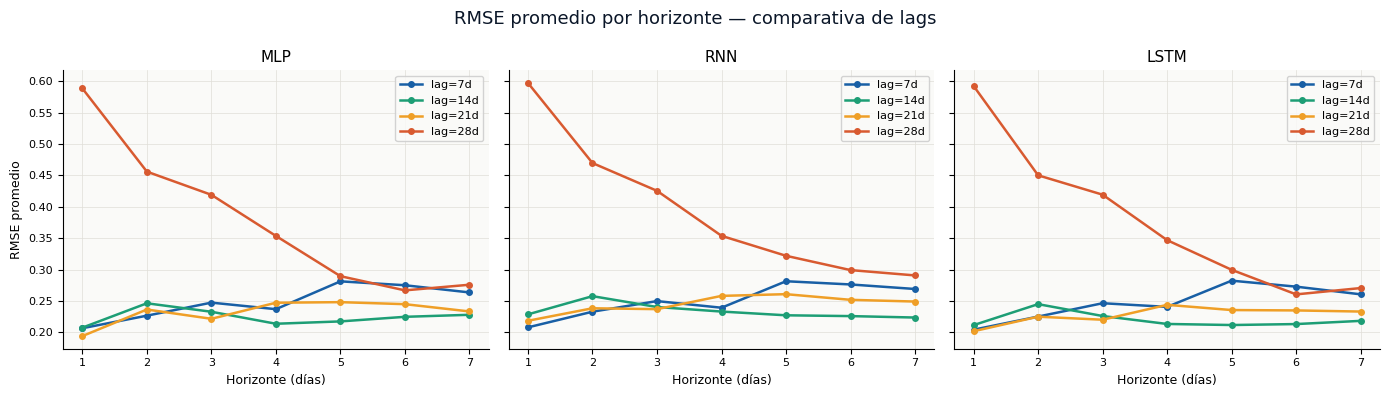

✅ Guardado: results/fig_rmse_por_horizonte.png


In [5]:
# ── Gráfica: RMSE por horizonte, curva por lag, faceta por modelo ────────────
df_h = df_long.groupby(['Model', 'Lag', 'Horizon'])['RMSE'].mean().reset_index()

fig, axes = plt.subplots(1, len(MTYPES), figsize=(14, 4), sharey=True)
fig.suptitle('RMSE promedio por horizonte — comparativa de lags', fontsize=13, fontweight='500', color=C['navy'])

for ax, mtype in zip(axes, MTYPES):
    for lag in LAGS_LIST:
        sub = df_h[(df_h['Model'] == mtype) & (df_h['Lag'] == lag)]
        ax.plot(sub['Horizon'], sub['RMSE'], marker='o', markersize=4,
                color=LAG_COLORS[lag], linewidth=1.8, label=f'lag={lag}d')
    ax.set_title(mtype, fontweight='500')
    ax.set_xlabel('Horizonte (días)')
    ax.set_xticks(range(1, N_STEPS_FORECAST + 1))
    if ax == axes[0]:
        ax.set_ylabel('RMSE promedio')
    ax.legend()

plt.tight_layout()
plt.savefig('results/fig_rmse_por_horizonte.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: results/fig_rmse_por_horizonte.png')

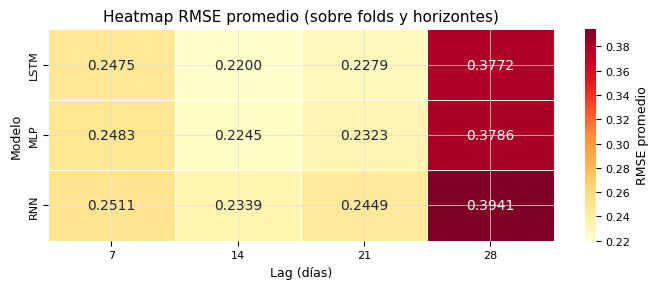

✅ Guardado: results/fig_heatmap_rmse.png


In [6]:
# ── Heatmap: RMSE promedio por (modelo × lag) ────────────────────────────────
pivot = (
    df_long.groupby(['Model', 'Lag'])['RMSE']
    .mean()
    .unstack('Lag')
    .round(4)
)

fig, ax = plt.subplots(figsize=(7, 3))
sns.heatmap(
    pivot, annot=True, fmt='.4f', cmap='YlOrRd',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'RMSE promedio'}
)
ax.set_title('Heatmap RMSE promedio (sobre folds y horizontes)', fontweight='500')
ax.set_xlabel('Lag (días)')
ax.set_ylabel('Modelo')
plt.tight_layout()
plt.savefig('results/fig_heatmap_rmse.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: results/fig_heatmap_rmse.png')

In [7]:
# ── Tabla detallada por fold para cada (modelo, lag) ─────────────────────────
os.makedirs('results', exist_ok=True)

for mtype in MTYPES:
    rows_t = []
    for lag in LAGS_LIST:
        for fold in FOLDS:
            r = results_all[mtype][lag][fold]
            m = r['metrics_test']
            row = {'Lag': lag, 'Fold': fold}
            for h in range(1, N_STEPS_FORECAST + 1):
                row[f'MAPE_h{h}'] = m[f'h{h}']['MAPE']
                row[f'RMSE_h{h}'] = m[f'h{h}']['RMSE']
            row['MAPE_mean'] = m['mean']['MAPE']
            row['MAE_mean']  = m['mean']['MAE']
            row['RMSE_mean'] = m['mean']['RMSE']
            row['MSE_mean']  = m['mean']['MSE']
            row['BDS_pval']  = r['bds_pval']
            rows_t.append(row)
    df_t = pd.DataFrame(rows_t)
    df_t.to_csv(f'results/metrics_{mtype}_full.csv', index=False)

print('✅ Tablas detalladas guardadas en results/metrics_{modelo}_full.csv')

✅ Tablas detalladas guardadas en results/metrics_{modelo}_full.csv


## 3. Test BDS en residuos (h=1)

In [8]:
# ── Tabla BDS: p-value por (modelo, lag, fold) ───────────────────────────────
ALPHA = 0.05

bds_rows = []
for mtype in MTYPES:
    for lag in LAGS_LIST:
        for fold in FOLDS:
            r = results_all[mtype][lag][fold]
            pval = r['bds_pval']
            bds_rows.append({
                'Model':   mtype,
                'Lag':     lag,
                'Fold':    fold,
                'BDS_pval': round(pval, 4),
                'Result':  'OK ✅' if pval > ALPHA else 'WARN ⚠️',
            })

df_bds = pd.DataFrame(bds_rows)

# Resumen: % folds que pasan por (modelo, lag)
bds_summary = (
    df_bds.groupby(['Model', 'Lag'])
    .apply(lambda g: pd.Series({
        'p_mean':   round(g['BDS_pval'].mean(), 4),
        'p_min':    round(g['BDS_pval'].min(), 4),
        'p_max':    round(g['BDS_pval'].max(), 4),
        'OK_folds': f"{(g['BDS_pval'] > ALPHA).sum()}/{len(g)}",
    }))
    .reset_index()
)

print('── Resumen BDS test (max_dim=2, h=1) ────────────────────────────────')
display(bds_summary.set_index(['Model', 'Lag']))

df_bds.to_csv('results/bds_pvalues.csv', index=False)
print('\n✅ Guardado: results/bds_pvalues.csv')

── Resumen BDS test (max_dim=2, h=1) ────────────────────────────────


p_mean   p_min   p_max OK_folds
Model Lag                                 
LSTM  7    0.9423  0.9075  0.9943      5/5
      14   0.9517  0.9164  0.9945      5/5
      21   0.9423  0.9122  0.9831      5/5
      28   0.9484  0.9013  0.9795      5/5
MLP   7    0.9591  0.9118  0.9975      5/5
      14   0.9644  0.9086  0.9919      5/5
      21   0.9476  0.8630  0.9957      5/5
      28   0.9712  0.9378  0.9968      5/5
RNN   7    0.9451  0.9024  0.9945      5/5
      14   0.9775  0.9508  0.9953      5/5
      21   0.9680  0.9555  0.9818      5/5
      28   0.9585  0.9148  0.9910      5/5


✅ Guardado: results/bds_pvalues.csv


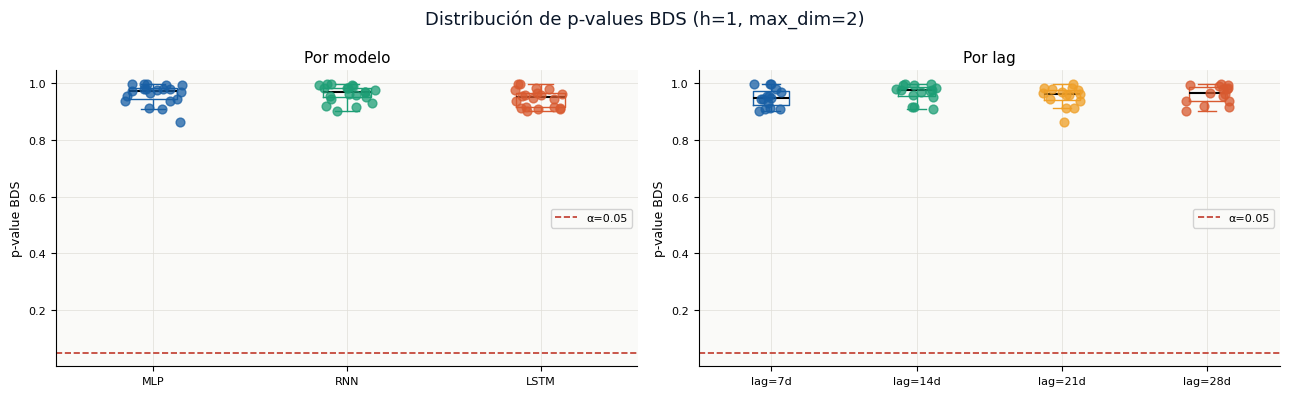

✅ Guardado: results/fig_bds_pvalues.png


In [9]:
# ── Gráfica: distribución de p-values BDS ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Distribución de p-values BDS (h=1, max_dim=2)', fontsize=13, fontweight='500', color=C['navy'])

# Panel izquierdo: stripplot por modelo
ax = axes[0]
for i, mtype in enumerate(MTYPES):
    sub = df_bds[df_bds['Model'] == mtype]['BDS_pval'].values
    jitter = np.random.uniform(-0.15, 0.15, len(sub))
    ax.scatter(np.full_like(sub, i) + jitter, sub,
               color=MODEL_COLORS[mtype], alpha=0.75, s=40, zorder=3)
    ax.boxplot(sub, positions=[i], widths=0.25,
               medianprops=dict(color='black', linewidth=1.5),
               boxprops=dict(color=MODEL_COLORS[mtype]),
               whiskerprops=dict(color=MODEL_COLORS[mtype]),
               capprops=dict(color=MODEL_COLORS[mtype]),
               flierprops=dict(marker=''))
ax.axhline(ALPHA, color=C['red'], linewidth=1.2, linestyle='--', label=f'α={ALPHA}')
ax.set_xticks(range(len(MTYPES)))
ax.set_xticklabels(MTYPES)
ax.set_ylabel('p-value BDS')
ax.set_title('Por modelo')
ax.legend()

# Panel derecho: stripplot por lag
ax = axes[1]
for i, lag in enumerate(LAGS_LIST):
    sub = df_bds[df_bds['Lag'] == lag]['BDS_pval'].values
    jitter = np.random.uniform(-0.15, 0.15, len(sub))
    ax.scatter(np.full_like(sub, i) + jitter, sub,
               color=LAG_COLORS[lag], alpha=0.75, s=40, zorder=3)
    ax.boxplot(sub, positions=[i], widths=0.25,
               medianprops=dict(color='black', linewidth=1.5),
               boxprops=dict(color=LAG_COLORS[lag]),
               whiskerprops=dict(color=LAG_COLORS[lag]),
               capprops=dict(color=LAG_COLORS[lag]),
               flierprops=dict(marker=''))
ax.axhline(ALPHA, color=C['red'], linewidth=1.2, linestyle='--', label=f'α={ALPHA}')
ax.set_xticks(range(len(LAGS_LIST)))
ax.set_xticklabels([f'lag={l}d' for l in LAGS_LIST])
ax.set_ylabel('p-value BDS')
ax.set_title('Por lag')
ax.legend()

plt.tight_layout()
plt.savefig('results/fig_bds_pvalues.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: results/fig_bds_pvalues.png')

## 4. Curvas train / val / test con predicciones

In [10]:
# ── Función auxiliar: gráfica de curvas para un (mtype, lag, fold) ───────────
def plot_forecast_curves(mtype, lag, fold, ax=None, title=None):
    """Plotea y_true vs yhat en train, val y test para un fold dado.
    Usa el horizonte h=1 (primera columna) para mantener la serie 1-D.
    """
    r = results_all[mtype][lag][fold]

    y_tr  = r['y_train_raw'][:, 0]
    y_val = r['y_val_raw'][:, 0]
    y_te  = r['y_test_raw'][:, 0]
    p_tr  = r['yhat_train'][:, 0]
    p_val = r['yhat_val'][:, 0]
    p_te  = r['yhat_test'][:, 0]

    n_tr  = len(y_tr)
    n_val = len(y_val)
    n_te  = len(y_te)

    # Ejes x contiguos
    x_tr  = np.arange(n_tr)
    x_val = np.arange(n_tr, n_tr + n_val)
    x_te  = np.arange(n_tr + n_val, n_tr + n_val + n_te)

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 3.5))

    # Bandas de fondo
    ax.axvspan(x_tr[0],  x_tr[-1],  alpha=0.05, color=C['blue'],   label='_nolegend_')
    ax.axvspan(x_val[0], x_val[-1], alpha=0.08, color=C['amber'],  label='_nolegend_')
    ax.axvspan(x_te[0],  x_te[-1],  alpha=0.08, color=C['coral'],  label='_nolegend_')

    # Series reales
    ax.plot(x_tr,  y_tr,  color=C['navy'], linewidth=0.8, alpha=0.6)
    ax.plot(x_val, y_val, color=C['navy'], linewidth=0.8, alpha=0.6)
    ax.plot(x_te,  y_te,  color=C['navy'], linewidth=0.8, alpha=0.6, label='Real')

    # Predicciones
    ax.plot(x_tr,  p_tr,  color=C['blue'],  linewidth=1.2, linestyle='--', alpha=0.8, label='Pred train')
    ax.plot(x_val, p_val, color=C['amber'], linewidth=1.2, linestyle='--', alpha=0.9, label='Pred val')
    ax.plot(x_te,  p_te,  color=C['coral'], linewidth=1.4, linestyle='--', label='Pred test')

    # Separadores verticales
    ax.axvline(x_val[0], color='gray', linewidth=0.8, linestyle=':')
    ax.axvline(x_te[0],  color='gray', linewidth=0.8, linestyle=':')

    # Anotaciones
    ax.text(x_tr.mean(),  ax.get_ylim()[1]*0.95, 'TRAIN', ha='center', fontsize=7, color=C['blue'],  alpha=0.7)
    ax.text(x_val.mean(), ax.get_ylim()[1]*0.95, 'VAL',   ha='center', fontsize=7, color=C['amber'], alpha=0.8)
    ax.text(x_te.mean(),  ax.get_ylim()[1]*0.95, 'TEST',  ha='center', fontsize=7, color=C['coral'])

    rmse = results_all[mtype][lag][fold]['rmse_test']
    ax.set_title(title or f'{mtype} | lag={lag}d | fold={fold} | RMSE_test={rmse:.4f}', fontsize=10)
    ax.set_xlabel('Muestra (h=1)')
    ax.set_ylabel('RV_15m')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}'))
    ax.legend(loc='upper left', ncol=3, fontsize=7)

print('✅ Función plot_forecast_curves definida')

✅ Función plot_forecast_curves definida


In [11]:
# ── Función: identificar mejor, peor y mediano por (mtype, lag) ──────────────
def get_fold_ranking(mtype, lag):
    """Devuelve dict con fold mejor, peor y mediano según rmse_test."""
    rmse_by_fold = {
        f: results_all[mtype][lag][f]['rmse_test']
        for f in FOLDS
    }
    sorted_folds = sorted(rmse_by_fold, key=rmse_by_fold.get)
    n = len(sorted_folds)
    return {
        'best':   sorted_folds[0],
        'median': sorted_folds[n // 2],
        'worst':  sorted_folds[-1],
        'rmse':   rmse_by_fold,
    }

print('✅ Función get_fold_ranking definida')

✅ Función get_fold_ranking definida


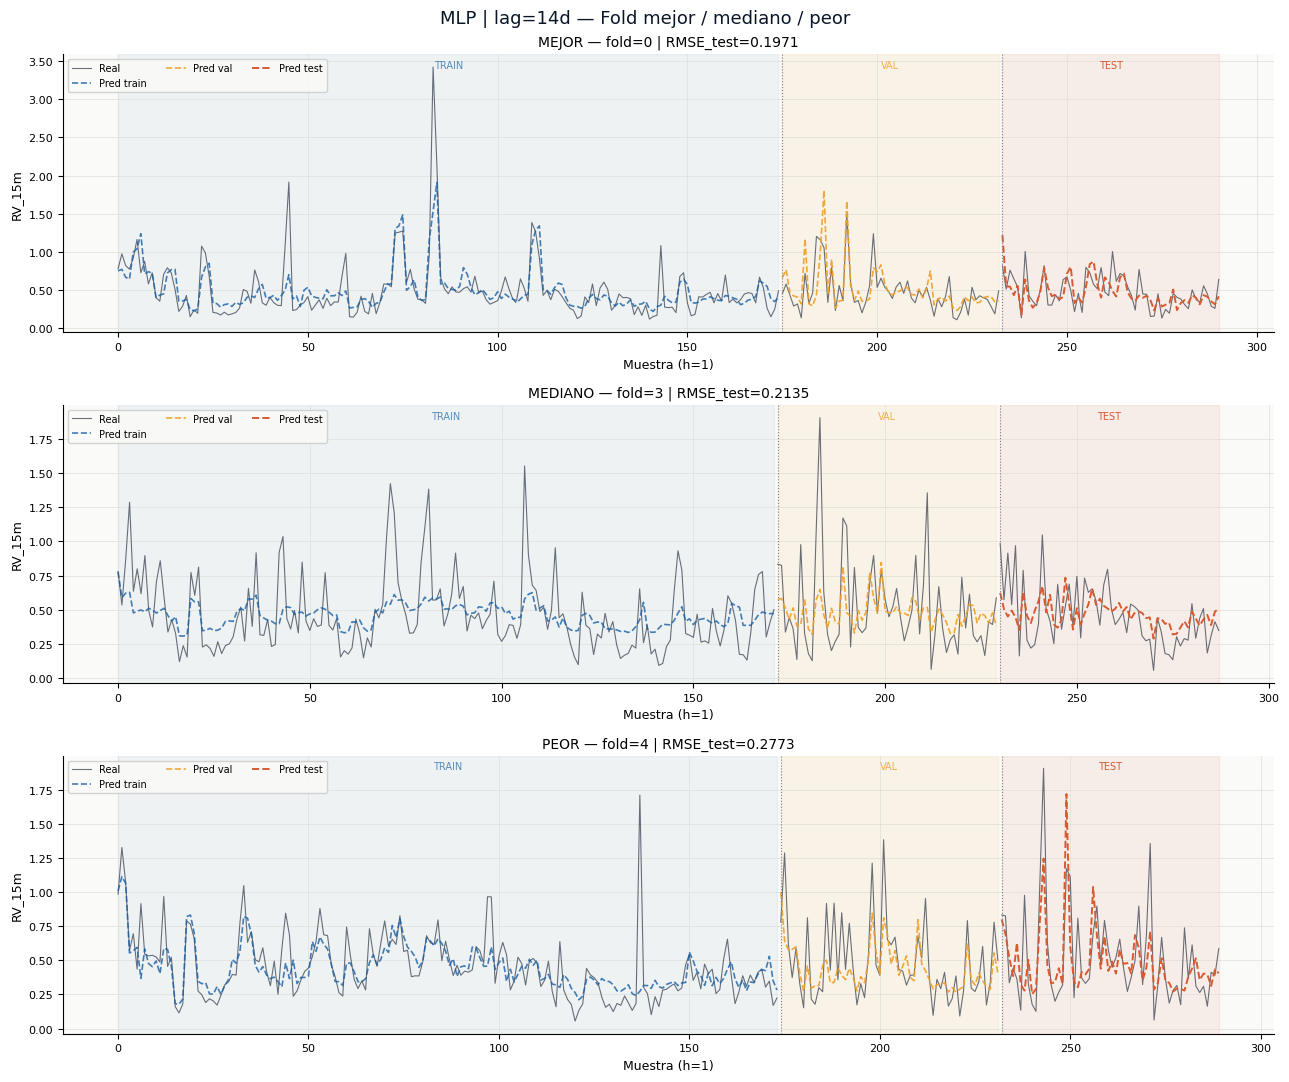

✅ Guardado: results/fig_curves_MLP_lag14.png


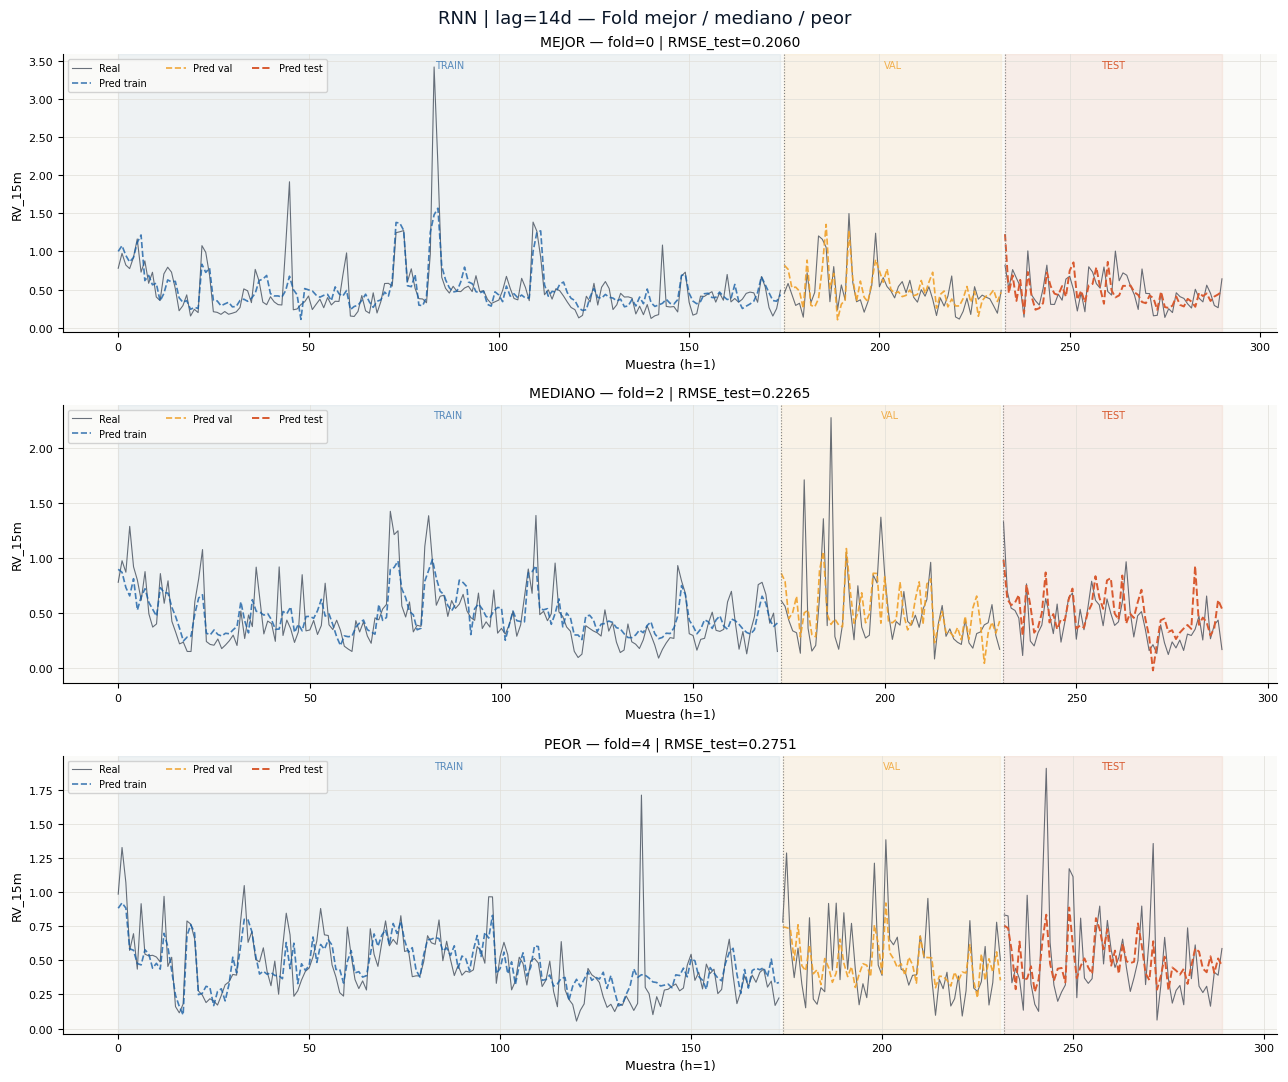

✅ Guardado: results/fig_curves_RNN_lag14.png


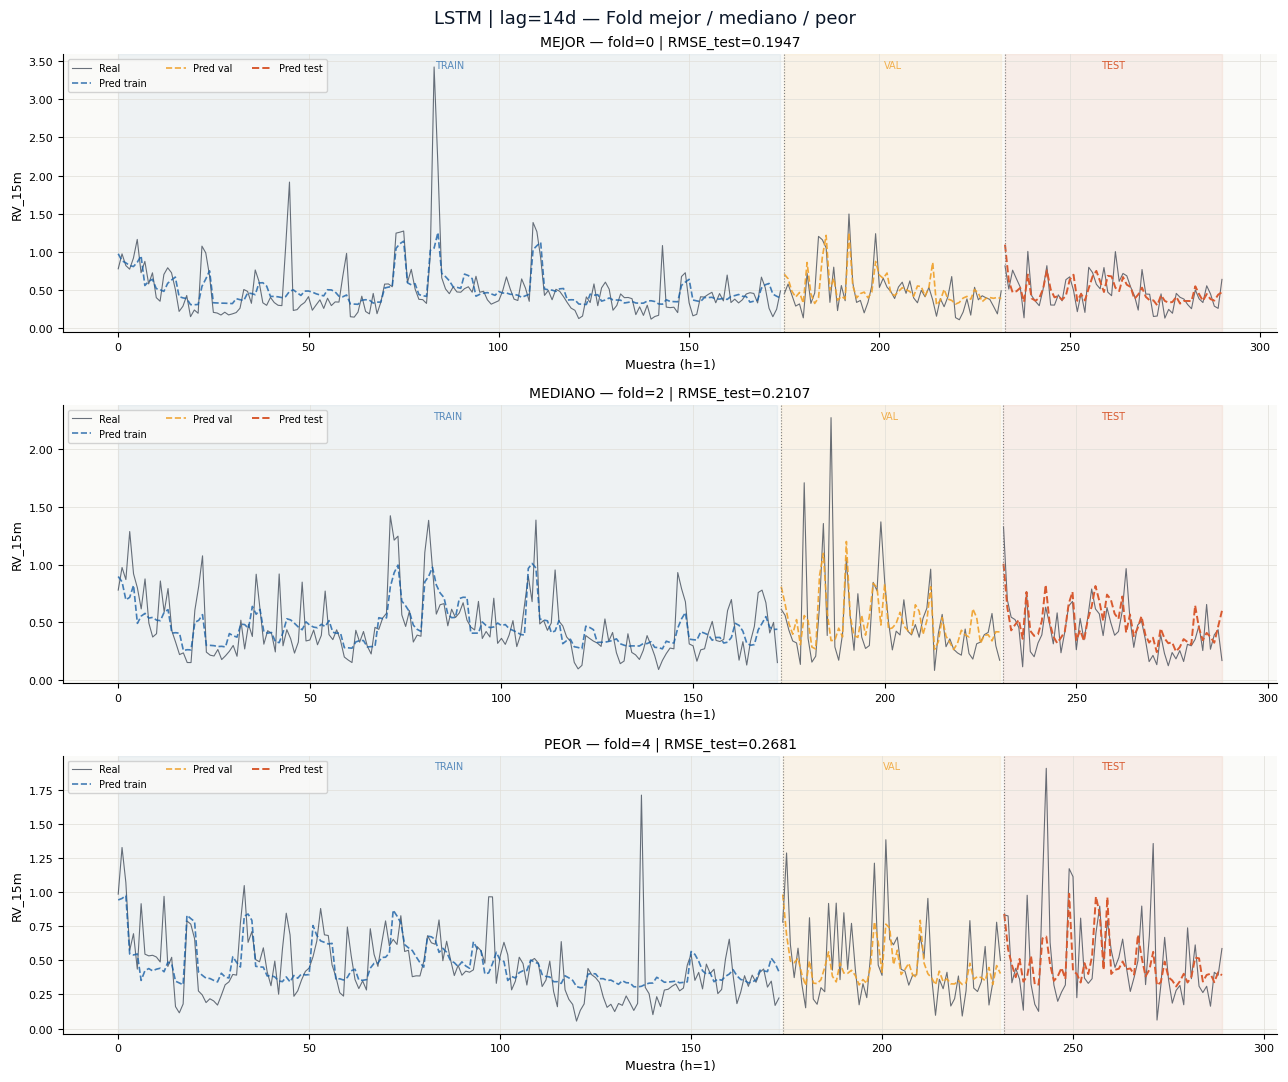

✅ Guardado: results/fig_curves_LSTM_lag14.png


In [12]:
# ── Curvas para cada (modelo, lag) — mejor / mediano / peor ─────────────────
# Genera una figura de 3 filas por cada combinación (modelo × lag)
# Para no generar demasiadas figuras, se puede filtrar el lag de interés.
# Cambiar LAG_PLOT y MODEL_PLOT para explorar otras combinaciones.

LAG_PLOT   = 14          # lag principal de interés
MODEL_PLOT = MTYPES      # todos los modelos; cambia a ['MLP'] para solo uno

for mtype in MODEL_PLOT:
    ranking = get_fold_ranking(mtype, LAG_PLOT)
    fig, axes = plt.subplots(3, 1, figsize=(13, 11))
    fig.suptitle(
        f'{mtype} | lag={LAG_PLOT}d — Fold mejor / mediano / peor',
        fontsize=13, fontweight='500', color=C['navy']
    )
    for ax, (label, fold) in zip(axes, [
        ('MEJOR',   ranking['best']),
        ('MEDIANO', ranking['median']),
        ('PEOR',    ranking['worst']),
    ]):
        rmse = ranking['rmse'][fold]
        plot_forecast_curves(
            mtype, LAG_PLOT, fold, ax=ax,
            title=f'{label} — fold={fold} | RMSE_test={rmse:.4f}'
        )
    plt.tight_layout()
    plt.savefig(f'results/fig_curves_{mtype}_lag{LAG_PLOT}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Guardado: results/fig_curves_{mtype}_lag{LAG_PLOT}.png')

## 5. RMSE por fold y por horizonte

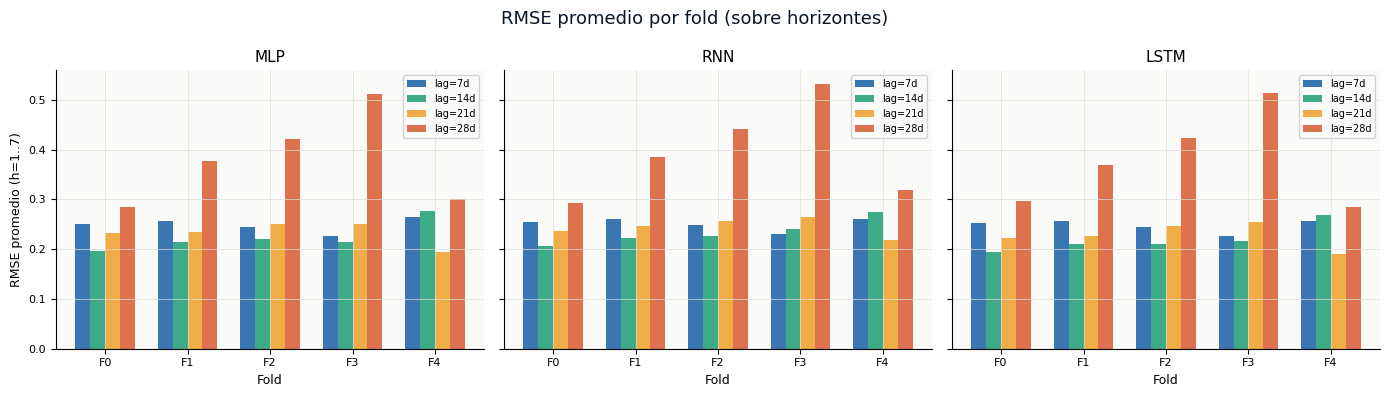

✅ Guardado: results/fig_rmse_por_fold.png


In [13]:
# ── Panel 1: RMSE por fold (promedio sobre horizontes) ───────────────────────
# Gráfica de barras: eje x = fold, eje y = RMSE promedio, color = lag
# Facetas: un subplot por modelo

df_fold = df_long.groupby(['Model', 'Lag', 'Fold'])['RMSE'].mean().reset_index()

fig, axes = plt.subplots(1, len(MTYPES), figsize=(14, 4), sharey=True)
fig.suptitle('RMSE promedio por fold (sobre horizontes)', fontsize=13, fontweight='500', color=C['navy'])

bar_width = 0.18
x = np.arange(len(FOLDS))

for ax, mtype in zip(axes, MTYPES):
    for j, lag in enumerate(LAGS_LIST):
        sub = df_fold[(df_fold['Model'] == mtype) & (df_fold['Lag'] == lag)]
        offset = (j - len(LAGS_LIST)/2 + 0.5) * bar_width
        ax.bar(x + offset, sub['RMSE'].values, width=bar_width,
               color=LAG_COLORS[lag], alpha=0.85, label=f'lag={lag}d')
    ax.set_title(mtype, fontweight='500')
    ax.set_xlabel('Fold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'F{f}' for f in FOLDS])
    if ax == axes[0]:
        ax.set_ylabel('RMSE promedio (h=1..7)')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('results/fig_rmse_por_fold.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: results/fig_rmse_por_fold.png')

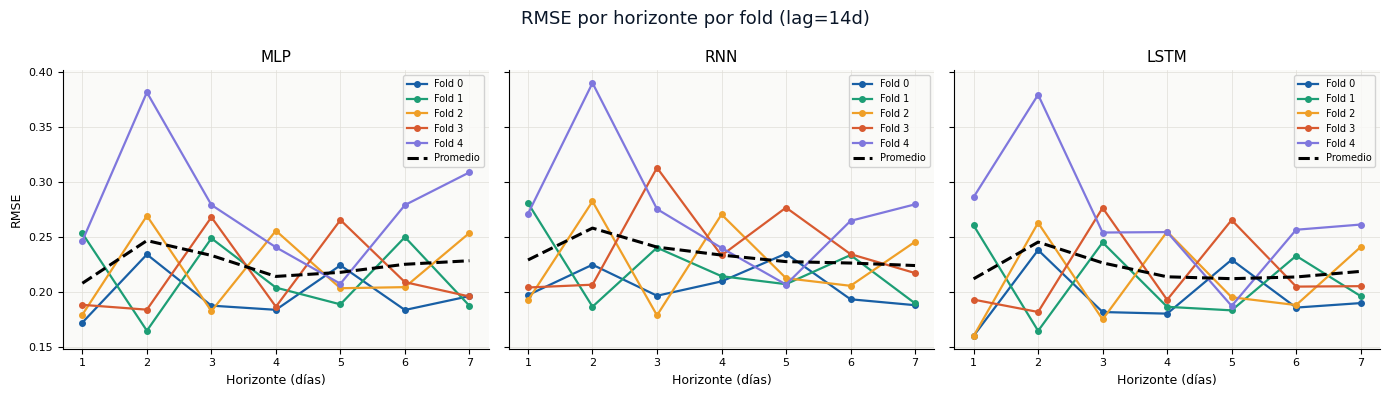

✅ Guardado: results/fig_rmse_horizonte_fold_lag14.png


In [14]:
# ── Panel 2: RMSE por horizonte (promedio sobre folds) ───────────────────────
# Gráfica de líneas: eje x = horizonte, eje y = RMSE, color = fold
# Facetas: un subplot por modelo; lag fijo en LAG_PLOT

df_hf = df_long[df_long['Lag'] == LAG_PLOT].groupby(['Model', 'Fold', 'Horizon'])['RMSE'].mean().reset_index()

fig, axes = plt.subplots(1, len(MTYPES), figsize=(14, 4), sharey=True)
fig.suptitle(f'RMSE por horizonte por fold (lag={LAG_PLOT}d)', fontsize=13, fontweight='500', color=C['navy'])

for ax, mtype in zip(axes, MTYPES):
    for i, fold in enumerate(FOLDS):
        sub = df_hf[(df_hf['Model'] == mtype) & (df_hf['Fold'] == fold)]
        ax.plot(sub['Horizon'], sub['RMSE'], marker='o', markersize=4,
                color=FOLD_COLORS[i], linewidth=1.6, label=f'Fold {fold}')
    # Promedio sobre folds en negro
    mean_sub = df_hf[df_hf['Model'] == mtype].groupby('Horizon')['RMSE'].mean()
    ax.plot(mean_sub.index, mean_sub.values, color='black', linewidth=2.2,
            linestyle='--', label='Promedio', zorder=5)
    ax.set_title(mtype, fontweight='500')
    ax.set_xlabel('Horizonte (días)')
    ax.set_xticks(range(1, N_STEPS_FORECAST + 1))
    if ax == axes[0]:
        ax.set_ylabel('RMSE')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(f'results/fig_rmse_horizonte_fold_lag{LAG_PLOT}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Guardado: results/fig_rmse_horizonte_fold_lag{LAG_PLOT}.png')

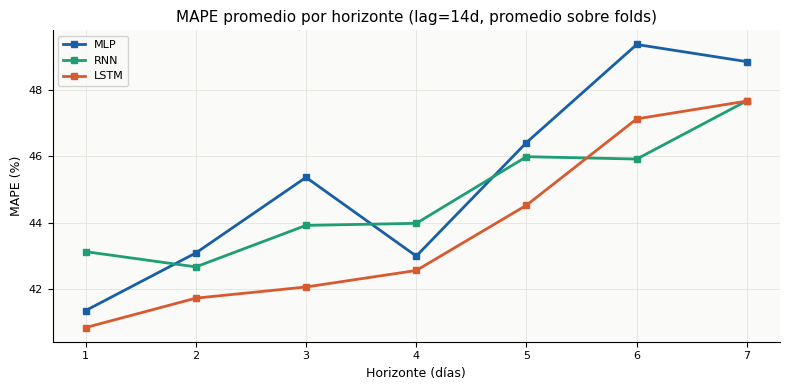

✅ Guardado: results/fig_mape_horizonte_lag14.png


In [15]:
# ── Panel 3: MAPE por horizonte — comparativa de modelos ─────────────────────
df_mape = df_long[df_long['Lag'] == LAG_PLOT].groupby(['Model', 'Horizon'])['MAPE'].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
for mtype in MTYPES:
    sub = df_mape[df_mape['Model'] == mtype]
    ax.plot(sub['Horizon'], sub['MAPE'], marker='s', markersize=5,
            color=MODEL_COLORS[mtype], linewidth=2, label=mtype)

ax.set_title(f'MAPE promedio por horizonte (lag={LAG_PLOT}d, promedio sobre folds)',
             fontweight='500')
ax.set_xlabel('Horizonte (días)')
ax.set_ylabel('MAPE (%)')
ax.set_xticks(range(1, N_STEPS_FORECAST + 1))
ax.legend()
plt.tight_layout()
plt.savefig(f'results/fig_mape_horizonte_lag{LAG_PLOT}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Guardado: results/fig_mape_horizonte_lag{LAG_PLOT}.png')

## 6. Mejor modelo global y conclusiones

In [16]:
# ── Recalcular best_global desde results_all ─────────────────────────────────
best = {'rmse': np.inf, 'mtype': None, 'lag': None, 'fold': None}
for mtype in MTYPES:
    for lag in LAGS_LIST:
        for fold in FOLDS:
            r = results_all[mtype][lag][fold]
            if r['rmse_test'] < best['rmse']:
                best = {'rmse': r['rmse_test'], 'mtype': mtype, 'lag': lag, 'fold': fold}

r_best = results_all[best['mtype']][best['lag']][best['fold']]
m_best = r_best['metrics_test']

print(f"\n{'='*60}")
print(f"  MEJOR MODELO GLOBAL")
print(f"{'='*60}")
print(f"  Tipo    : {best['mtype']}")
print(f"  Lag     : {best['lag']}d")
print(f"  Fold    : {best['fold']}")
print(f"  RMSE    : {best['rmse']:.4f}")
print(f"  MAPE    : {m_best['mean']['MAPE']:.2f}%")
print(f"  MAE     : {m_best['mean']['MAE']:.4f}")
print(f"  BDS p   : {r_best['bds_pval']:.4f} ({'OK ✅' if r_best['bds_pval'] > 0.05 else 'WARN ⚠️'})")
if best_configs:
    bc = best_configs[best['mtype']]
    print(f"  Arch    : {bc['arquitectura']}")
    print(f"  Dropout : {bc['dropout_mask']}")
print(f"{'='*60}")


  MEJOR MODELO GLOBAL
  Tipo    : LSTM
  Lag     : 21d
  Fold    : 4
  RMSE    : 0.1896
  MAPE    : 41.11%
  MAE     : 0.1390
  BDS p   : 0.9590 (OK ✅)
  Arch    : (32,)
  Dropout : (True,)


In [17]:
# ── Tabla resumen final de los 3 modelos (lag óptimo por modelo) ─────────────
# Para cada modelo: elige el lag con menor RMSE promedio sobre folds
final_rows = []
for mtype in MTYPES:
    best_lag_rmse = {}
    for lag in LAGS_LIST:
        rmse_folds = [results_all[mtype][lag][f]['rmse_test'] for f in FOLDS]
        best_lag_rmse[lag] = np.mean(rmse_folds)
    opt_lag  = min(best_lag_rmse, key=best_lag_rmse.get)
    mape_folds = [
        results_all[mtype][opt_lag][f]['metrics_test']['mean']['MAPE']
        for f in FOLDS
    ]
    bds_folds  = [results_all[mtype][opt_lag][f]['bds_pval'] for f in FOLDS]
    final_rows.append({
        'Model':           mtype,
        'Lag óptimo (d)':  opt_lag,
        'RMSE mean±std':   f"{best_lag_rmse[opt_lag]:.4f} ± {np.std([results_all[mtype][opt_lag][f]['rmse_test'] for f in FOLDS]):.4f}",
        'MAPE mean±std':   f"{np.mean(mape_folds):.2f}% ± {np.std(mape_folds):.2f}%",
        'BDS OK folds':    f"{sum(1 for p in bds_folds if p > 0.05)}/{len(FOLDS)}",
        'BDS p mean':      f"{np.mean(bds_folds):.4f}",
    })

df_final = pd.DataFrame(final_rows)
print('── Tabla final — mejor lag por modelo ──────────────────────────────')
display(df_final.set_index('Model'))
df_final.to_csv('results/summary_final.csv', index=False)
print('\n✅ Guardado: results/summary_final.csv')

── Tabla final — mejor lag por modelo ──────────────────────────────


,Lag óptimo (d),RMSE mean±std,MAPE mean±std,BDS OK folds,BDS p mean
Model,,,,,
MLP,14,0.2245 ± 0.0275,45.34% ± 3.79%,5/5,0.9644
RNN,14,0.2339 ± 0.0233,44.75% ± 4.37%,5/5,0.9775
LSTM,14,0.2200 ± 0.0252,43.78% ± 1.12%,5/5,0.9517



✅ Guardado: results/summary_final.csv


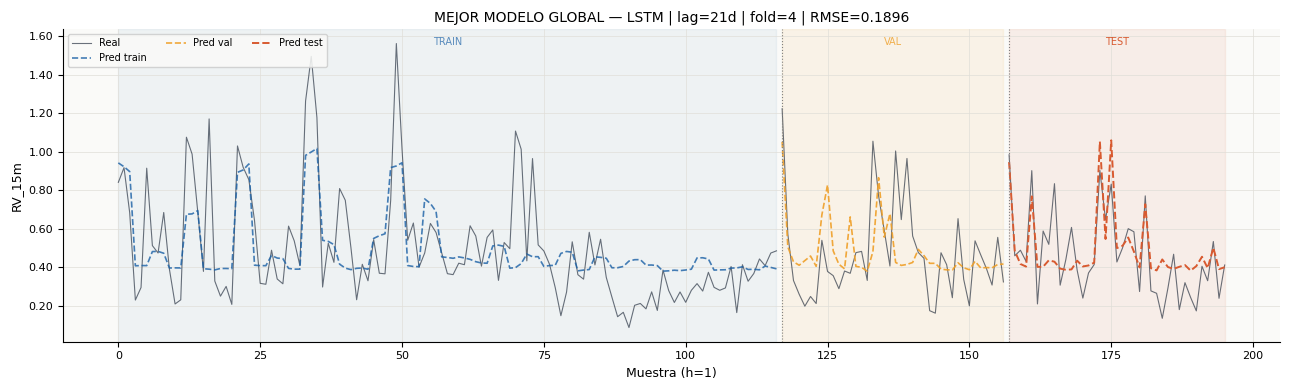

✅ Guardado: results/fig_best_model_curves.png


In [18]:
# ── Curva del mejor modelo global ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
plot_forecast_curves(
    best['mtype'], best['lag'], best['fold'], ax=ax,
    title=(
        f"MEJOR MODELO GLOBAL — {best['mtype']} | lag={best['lag']}d | "
        f"fold={best['fold']} | RMSE={best['rmse']:.4f}"
    )
)
plt.tight_layout()
plt.savefig('results/fig_best_model_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: results/fig_best_model_curves.png')

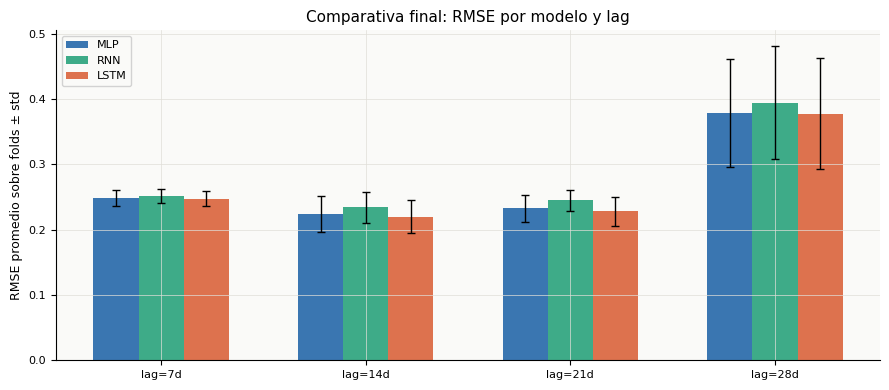

✅ Guardado: results/fig_comparativa_final.png

✅ Evaluación completa.


In [19]:
# ── Gráfica comparativa de modelos — RMSE por lag (barras con error) ─────────
fig, ax = plt.subplots(figsize=(9, 4))

bar_width = 0.22
x = np.arange(len(LAGS_LIST))

for j, mtype in enumerate(MTYPES):
    means = []
    stds  = []
    for lag in LAGS_LIST:
        vals = [results_all[mtype][lag][f]['rmse_test'] for f in FOLDS]
        means.append(np.mean(vals))
        stds.append(np.std(vals))
    offset = (j - len(MTYPES)/2 + 0.5) * bar_width
    ax.bar(x + offset, means, width=bar_width,
           color=MODEL_COLORS[mtype], alpha=0.85, label=mtype,
           yerr=stds, capsize=3, error_kw={'linewidth': 1})

ax.set_xticks(x)
ax.set_xticklabels([f'lag={l}d' for l in LAGS_LIST])
ax.set_ylabel('RMSE promedio sobre folds ± std')
ax.set_title('Comparativa final: RMSE por modelo y lag', fontweight='500')
ax.legend()
plt.tight_layout()
plt.savefig('results/fig_comparativa_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: results/fig_comparativa_final.png')
print('\n✅ Evaluación completa.')